# Running a baroclinic instability test case

First we set up the mpi environment:

In [1]:
import ipyparallel as ipp
ntiles = 6
layout = (1, 1)

num_ranks = ntiles * layout[0] * layout[1]
cluster = ipp.Cluster(engines="mpi", n=num_ranks).start_and_connect_sync()

# start executing cells on the workers in parallel from here on
%autopx

Starting 6 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:05<00:00,  1.05engine/s]
%autopx enabled


[0:execute]
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
Cell In[6], line 1
----> 1 get_ipython().run_cell_magic('time', '', '# driver.step_one(0)\ntry:\n    driver.step_all()\nfinally:\n    driver.cleanup()\n')

File <timed exec>:5
      1 'Could not get source, probably due dynamically evaluated source code.'

File /pace/pace/driver.py:829, in Driver.step_all(self)
    827 PerformanceCollector.mark_cuda_profiler("Begin integration")
    828 PerformanceCollector.start_cuda_profiler()
--> 829 self._critical_path_step_all(
    830     steps_count=self.config.n_timesteps(),
    831     timer=self.performance_collector.timestep_timer,
    832     dt=Float(self.config.timestep.total_seconds()),
    833 )
    834 PerformanceCollector.stop_cuda_profiler()
    835 self.profiler.dump_stats(
    836     f"{self.config.performance_config.experiment_name}_\
    837     {self.comm.Get_rank()}

[3:execute]
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
Cell In[6], line 1
----> 1 get_ipython().run_cell_magic('time', '', '# driver.step_one(0)\ntry:\n    driver.step_all()\nfinally:\n    driver.cleanup()\n')

File <timed exec>:5
      1 'Could not get source, probably due dynamically evaluated source code.'

File /pace/pace/driver.py:829, in Driver.step_all(self)
    827 PerformanceCollector.mark_cuda_profiler("Begin integration")
    828 PerformanceCollector.start_cuda_profiler()
--> 829 self._critical_path_step_all(
    830     steps_count=self.config.n_timesteps(),
    831     timer=self.performance_collector.timestep_timer,
    832     dt=Float(self.config.timestep.total_seconds()),
    833 )
    834 PerformanceCollector.stop_cuda_profiler()
    835 self.profiler.dump_stats(
    836     f"{self.config.performance_config.experiment_name}_\
    837     {self.comm.Get_rank()}

Double-check the MPI setup:

In [2]:
from mpi4py import MPI

mpi_comm = MPI.COMM_WORLD
mpi_size = mpi_comm.Get_size()
mpi_rank = mpi_comm.Get_rank()

print(f"I am MPI-rank {mpi_rank} of a total of {mpi_size}")

[stdout:1] I am MPI-rank 1 of a total of 6


[stdout:0] I am MPI-rank 0 of a total of 6


[stdout:2] I am MPI-rank 2 of a total of 6


[stdout:3] I am MPI-rank 3 of a total of 6


[stdout:5] I am MPI-rank 5 of a total of 6


[stdout:4] I am MPI-rank 4 of a total of 6


Next we set up the model driver using the yaml config file:

In [3]:
%%time

from pace import Driver, DriverConfig
import yaml

config_file = "baroclinic_c24.yaml"

with open(config_file, "r") as f:
    driver_config = DriverConfig.from_dict(yaml.safe_load(f))
driver = Driver(config=driver_config)

[output:4]

[output:0]

[output:1]

[output:5]

[output:3]

...

[stderr:5] /usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `p_ref` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `rf` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `dmdir` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `coszenm` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `zt__fa8_157_25` may be 

[stderr:3] /usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `p_ref` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `rf` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `dmdir` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `coszenm` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `zt__fa8_157_25` may be 

[stderr:2] /usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/site-packages/ndsl/grid/gnomonic.py:681: RuntimeWarning: invalid value encountered in divide
  np.sum(p * q, axis=-1) / np.sqrt(np.sum(p**2, axis=-1) * np.sum(q**2, axis=-1))
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `p_ref` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `rf` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `dmdir` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.

[stderr:1] /usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `p_ref` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `rf` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `dmdir` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `coszenm` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `zt__fa8_157_25` may be 

%px: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [02:51<00:00, 28.66s/tasks]


In [4]:
if mpi_rank == 0:
    print(driver.state.grid_data.lon_agrid.shape)

[stdout:0] (31, 31)


We can inspect the initial model state:

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from cartopy import crs as ccrs
from fv3viz import pcolormesh_cube
from ndsl import CubedSphereCommunicator

communicator = CubedSphereCommunicator.from_layout(
    comm=driver.comm,
    layout=driver.config.layout,
)
u_wind = communicator.gather(driver.state.dycore_state.u)
temperature = communicator.gather(driver.state.dycore_state.pt)
surface_pressure = communicator.gather(driver.state.dycore_state.ps)
grid_lon = communicator.gather(driver.state.grid_data.lon)
grid_lat = communicator.gather(driver.state.grid_data.lat)
a_lon = communicator.gather(driver.state.grid_data.lon_agrid)
a_lat = communicator.gather(driver.state.grid_data.lat_agrid)

[output:0]

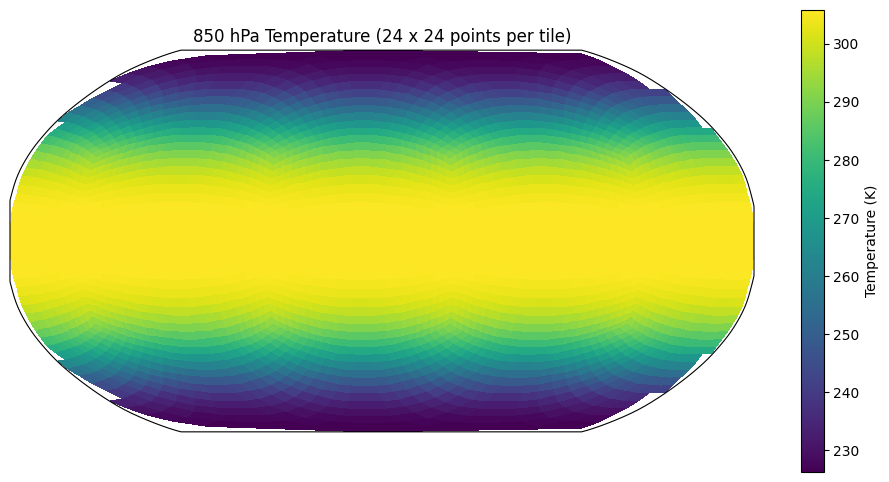

In [6]:
if mpi_rank == 0:
    u_mean = 0.5 * (u_wind.data[:,:,:-1, :] + u_wind.data[:,:, 1:, :])
    
    nx = temperature.shape[1]
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi,
        temperature.data[:, :, :, -2],
        cmap="viridis",
    )
    plt.colorbar(f1, label="Temperature (K)")
    ax.set_title(f"850 hPa Temperature ({nx} x {nx} points per tile)")
    
#     fig = plt.figure(figsize=(12, 6))
#     ax = fig.add_subplot(111, projection=ccrs.Robinson())
#     f1 = pcolormesh_cube(
#         grid_lat.data * 180./np.pi,
#         grid_lon.data * 180./np.pi,
#         surface_pressure.data[:, :, :]/100.,
#         cmap="viridis",
#     )
#     plt.colorbar(f1, label="Surface Pressure (hPa)")
#     ax.set_title(f"Surface Pressure ({nx} x {nx} points per tile)")
    
    
#     fig = plt.figure(figsize=(12, 6))
#     ax = fig.add_subplot(111, projection=ccrs.Robinson())
#     f1 = pcolormesh_cube(
#         grid_lat.data * 180./np.pi,
#         grid_lon.data * 180./np.pi,
#         u_mean[:,:,:,65],
#         cmap="bwr",
#     )
#     plt.colorbar(f1, label="U wind (m/s)")
#     ax.set_title(f"U Wind ({nx} x {nx} points per tile)")

# And then we can run the model:

In [ ]:
%%time
# driver.step_one(0)
try:
    driver.step_all()
finally:
    driver.cleanup()

[stdout:0] 2026-04-10 16:30:09|INFO|rank 0|ndsl.logging:integrating driver forward in time
2026-04-10 16:30:09|INFO|rank 0|ndsl.logging:FV Setup
2026-04-10 16:30:09|INFO|rank 0|ndsl.logging:Adjust pt
2026-04-10 16:30:09|WARNING|rank 0|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 0|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 24 < 30.
2026-04-10 16:30:09|INFO|rank 0|ndsl.logging:DynCore
2026-04-10 16:30:09|WARNING|rank 0|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-04-10 16:30:09|WARNING|rank 0|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis j: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 0|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis i: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 0|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis j_interface: 25 < 30.
2

[stdout:2] 2026-04-10 16:30:09|INFO|rank 2|ndsl.logging:integrating driver forward in time
2026-04-10 16:30:09|WARNING|rank 2|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 2|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 2|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-04-10 16:30:09|WARNING|rank 2|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis j: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 2|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis i: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 2|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis j_interface: 25 < 30.
2026-04-10 16:30:09|WARNING|rank 2|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-04-10 16:30:09|WARNING|rank 

[stdout:4] 2026-04-10 16:30:09|INFO|rank 4|ndsl.logging:integrating driver forward in time
2026-04-10 16:30:09|WARNING|rank 4|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 4|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 4|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-04-10 16:30:09|WARNING|rank 4|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis j: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 4|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis i: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 4|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis j_interface: 25 < 30.
2026-04-10 16:30:09|WARNING|rank 4|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-04-10 16:30:09|WARNING|rank 

[stdout:1] 2026-04-10 16:30:09|INFO|rank 1|ndsl.logging:integrating driver forward in time
2026-04-10 16:30:09|WARNING|rank 1|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 1|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 1|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-04-10 16:30:09|WARNING|rank 1|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis j: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 1|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis i: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 1|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis j_interface: 25 < 30.
2026-04-10 16:30:09|WARNING|rank 1|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-04-10 16:30:09|WARNING|rank 

[stdout:3] 2026-04-10 16:30:09|INFO|rank 3|ndsl.logging:integrating driver forward in time
2026-04-10 16:30:09|WARNING|rank 3|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 3|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 3|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-04-10 16:30:09|WARNING|rank 3|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis j: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 3|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis i: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 3|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis j_interface: 25 < 30.
2026-04-10 16:30:09|WARNING|rank 3|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-04-10 16:30:09|WARNING|rank 

[stdout:5] 2026-04-10 16:30:09|INFO|rank 5|ndsl.logging:integrating driver forward in time
2026-04-10 16:30:09|WARNING|rank 5|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 5|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 5|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-04-10 16:30:09|WARNING|rank 5|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis j: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 5|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis i: 24 < 30.
2026-04-10 16:30:09|WARNING|rank 5|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis j_interface: 25 < 30.
2026-04-10 16:30:09|WARNING|rank 5|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-04-10 16:30:09|WARNING|rank 

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



%px:  83%|█████████████████████████████████████████████████████████████████████████████████▋                | 5/6 [02:09<00:01,  1.50s/tasks]

# Now let's investigate the model state

In [ ]:
u_wind = communicator.gather(driver.state.dycore_state.u)
temperature = communicator.gather(driver.state.dycore_state.pt)
surface_pressure = communicator.gather(driver.state.dycore_state.ps)
grid_lon = communicator.gather(driver.state.grid_data.lon)
grid_lat = communicator.gather(driver.state.grid_data.lat)
a_lon = communicator.gather(driver.state.grid_data.lon_agrid)
a_lat = communicator.gather(driver.state.grid_data.lat_agrid)
qvap = communicator.gather(driver.state.dycore_state.qvapor)
qcld = communicator.gather(driver.state.dycore_state.qcld)
qrain = communicator.gather(driver.state.dycore_state.qrain)
surface_temperature = communicator.gather(driver.state.sfc_state.tsfc)
prsl = communicator.gather(driver.state.radiation_state.prsl)
prsi = communicator.gather(driver.state.radiation_state.prsi)

In [ ]:
if mpi_rank == 0:
    rotation = -120.
    nx = temperature.shape[1]
    nz = temperature.shape[3]
    
    u_mean = 0.5 * (u_wind.data[:,:,:-1, :] + u_wind.data[:,:, 1:, :])
    column_qvap = np.sum(qvap, axis=3)/nz
    column_qcld = np.sum(qcld, axis=3)/nz
    column_qrain = np.sum(qrain, axis=3)/nz
    
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qvap,
        cmap="viridis",
    )
    plt.colorbar(f1, label="water vapor mixing ratio")
    ax.set_title(f"Column-Integrated Water Vapor Mixing Ratio ({nx} x {nx} points per tile)")

In [ ]:
from dataclasses import InitVar, dataclass, field, fields
import ndsl.dsl.gt4py_utils as gt_utils

In [ ]:
if mpi_rank == 0:
    print(np.all(np.isnan(driver.physics._sfc._fh2.field[:])))
    print(np.all(np.isnan(driver.state.physics_state.delp.field[:])))
    print(driver.state.radiation_state.prsl.field[5,5,:])
#     print(driver.state.dycore_state.ua.field[5,5,:])
    print(driver.physics._qvapor1.field[5,5,:])
    print(driver.physics._hydro_delp)
    print(np.any(driver.state.sfc_state.phil.field==0))
    print(driver.state.sfc_state.prslk.field.max())
#     print(driver.state.sfc_state.hflx.field)
#     print(driver.state.physics_state.tsfc.field[:])
#     print(driver.physics._prescribe_sst)
#     plt.imshow(driver.state.sfc_state.zorl.field[:]/9.81)
    print("huh")
    for r in range(6):
        print(prsl.field[r, :, :, :].min(), prsl.field[r, :, :, :].max())
        print(prsi.field[r, :, :, :].min(), prsi.field[r, :, :, :].max())
    nans = []
    zeros = []
    for _field in fields(driver.state.dycore_state):
        if "dims" in _field.metadata.keys():
            arr = gt_utils.asarray(getattr(driver.state.dycore_state, _field.name).data)
            if np.any(np.isnan(arr)):
                nans.append(_field.name)
                print(f"NaNs in {_field.name}")
            if np.all(arr==0.0):
                zeros.append(_field.name)
    print("nans:", nans)
    print("zeros:", zeros)
    print(np.all(driver.state.radiation_state.mu0.field==0))
    plt.imshow(driver.state.sfc_state.tsfc.field[:])
    plt.colorbar()

In [ ]:
if mpi_rank == 0:
    rotation = -120.
    nx = temperature.shape[1]
    nz = temperature.shape[3]
    
    u_mean = 0.5 * (u_wind.data[:,:,:-1, :] + u_wind.data[:,:, 1:, :])
    column_qvap = np.sum(qvap, axis=3)/nz
    column_qcld = np.sum(qcld, axis=3)/nz
    column_qrain = np.sum(qrain, axis=3)/nz
    
#     fig = plt.figure(figsize=(12, 6))
#     ax = fig.add_subplot(111, projection=ccrs.Robinson())
#     f1 = pcolormesh_cube(
#         grid_lat.data * 180./np.pi,
#         grid_lon.data * 180./np.pi + rotation,
#         temperature.data[:, :, :, -2],
#         cmap="viridis",
#     )
#     plt.colorbar(f1, label="Temperature (K)")
#     ax.set_title(f"Temperature ({nx} x {nx} points per tile)")
    
#     fig = plt.figure(figsize=(12, 6))
#     ax = fig.add_subplot(111, projection=ccrs.Robinson())
#     f1 = pcolormesh_cube(
#         grid_lat.data * 180./np.pi,
#         grid_lon.data * 180./np.pi + rotation,
#         surface_pressure.data[:, :, :]/100.,
#         cmap="viridis",
#     )
#     plt.colorbar(f1, label="Surface Pressure (hPa)")
#     ax.set_title(f"Surface Pressure ({nx} x {nx} points per tile)")
    
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qvap,
        cmap="viridis",
    )
    plt.colorbar(f1, label="water vapor mixing ratio")
    ax.set_title(f"Column-Integrated Water Vapor Mixing Ratio ({nx} x {nx} points per tile)")
    

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qrain,
        cmap="viridis",
    )
    plt.colorbar(f1, label="rain mixing ratio")
    ax.set_title(f"Column-Integrated Rain Mixing Ratio ({nx} x {nx} points per tile)")
    
#     fig = plt.figure(figsize=(12, 6))
#     ax = fig.add_subplot(111, projection=ccrs.Robinson())
#     f1 = pcolormesh_cube(
#         grid_lat.data * 180./np.pi,
#         grid_lon.data * 180./np.pi + rotation,
#         column_qcld,
#         cmap="viridis",
#     )
#     plt.colorbar(f1, label="cloud mixing ratio")
#     ax.set_title(f"Column-Integrated Cloud Mixing Ratio ({nx} x {nx} points per tile)")

In [ ]:
if mpi_rank == 0:
    rotation = -120.
    nx = temperature.shape[1]
    nz = temperature.shape[3]
    print(surface_temperature.field[:].mean())
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        surface_temperature.data[:, :, :],
        cmap="viridis",
    )
    plt.colorbar(f1, label="Temperature (K)")
    ax.set_title(f"Surface Temperature ({nx} x {nx} points per tile)")

In [ ]:
if mpi_rank == 0:
    print(driver.state.radiation_state.tlyr.field.min())
    print(driver.state.radiation_state.prsi.field.min())
    plt.gca().invert_yaxis()
    plt.semilogy(driver.state.radiation_state.tlvl.field[3,3,1:], driver.state.radiation_state.prsi.field[3,3,1:])

In [ ]:
if mpi_rank == 0:
    nans = []
    zeros = []
#     for _field in fields(driver.physics.microphyics_state):
    for _field in fields(driver.state.physics_state):
        if "dims" in _field.metadata.keys():
#             arr = gt_utils.asarray(getattr(driver.physics.microphyics_state, _field.name).data)
            arr = gt_utils.asarray(getattr(driver.state.physics_state, _field.name).data)
            if np.any(np.isnan(arr)):
                nans.append(_field.name)
                print(f"NaNs in {_field.name}")
            if np.all(arr==0.0):
                zeros.append(_field.name)
    print("nans:", nans)
    print("zeros:", zeros)

In [ ]:
if mpi_rank == 0:
    nans = []
    zeros = []
    for _field in fields(driver.physics.shalconv_state):
        if "dims" in _field.metadata.keys():
            arr = gt_utils.asarray(getattr(driver.physics.shalconv_state, _field.name).data)
            if np.any(np.isnan(arr)):
                nans.append(_field.name)
                print(f"NaNs in {_field.name}")
            if np.all(arr==0.0):
                zeros.append(_field.name)
    print("nans:", nans)
    print("zeros:", zeros)

In [ ]:
if mpi_rank == 0:
    nans = []
    zeros = []
    for _field in fields(driver.physics.pbl_state):
        if "dims" in _field.metadata.keys():
            arr = gt_utils.asarray(getattr(driver.physics.pbl_state, _field.name).data)
            if np.any(np.isnan(arr)):
                nans.append(_field.name)
                print(f"NaNs in {_field.name}")
            if np.all(arr==0.0):
                zeros.append(_field.name)
    print("nans:", nans)
    print("zeros:", zeros)